# SLR Diagnostics — Root Cause Analysis

| Question | Where |
|---|---|
| Is the model accurate on the dataset? | Cell 4 — Accuracy / F1 |
| Which letters are failing? | Cell 5 — Per-class bar chart |
| Which letters confuse each other? | Cell 6 — Confusion matrix |
| Is threshold 0.75 too strict? | Cell 7 — Confidence + threshold sweep |
| Is the problem the live camera vs dataset? | Cell 11 — Live probability viewer |


## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2, mediapipe as mp, time, os, threading, queue
from collections import deque
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, top_k_accuracy_score
)
plt.rcParams["figure.dpi"] = 110
print("✓ Imports OK")

✓ Imports OK


## 1. Select Language

Set `LANGUAGE = "english"` or `"arabic"`.


In [ ]:
LANGUAGE = "english"   # <── change to "arabic" for ArSL

if LANGUAGE == "english":
    MODEL_PATH   = r"C:\Users\HADEEL GAMALELDIN\Desktop\SLR-Main\Letters_ORIGINAL\Base_Pipeline_English_Letters\asl_mediapipe_mlp_model_engineered.h5"
    DATASET_PATH = r"C:\Users\HADEEL GAMALELDIN\Desktop\SLR-Main\Letters_ORIGINAL\Base_Pipeline_English_Letters\asl_letters_engineered.csv"
    CLASS_LABELS = [
        "A","B","C","D","E","F","G","H",
        "I","J","K","L","M","N","O","P",
        "Q","R","S","T","U","V","W","X",
        "Y","Z","del","nothing","space"
    ]
    TITLE_PREFIX = "ASL (English)"
else:
    # ── V2.2 Production model (ASLAD-3000_v2 dataset, 32 classes) ──────────────
    MODEL_PATH   = r"C:\Users\HADEEL GAMALELDIN\Desktop\SLR-Main\Letters_ORIGINAL\ArSL (Arabic Letters)\arsl_mediapipe_mlp_model_bestV2.2.h5"
    DATASET_PATH = r"C:\Users\HADEEL GAMALELDIN\Desktop\SLR-Main\Letters_ORIGINAL\ArSL (Arabic Letters)\ASLAD-3000_v2.csv"
    CLASS_LABELS = [
        "ain",   "al",    "aleff", "bb",    "dal",   "dha",
        "dhad",  "fa",    "gaaf",  "ghain", "ha",    "haa",
        "jeem",  "kaaf",  "khaa",  "la",    "laam",  "meem",
        "nun",   "ra",    "saad",  "seen",  "sheen", "ta",
        "taa",   "thaa",  "thal",  "toot",  "waw",   "ya",
        "yaa",   "zay"
    ]
    TITLE_PREFIX = "ArSL V2.2 Production (32 classes)"

print(f"Language : {LANGUAGE.upper()}")
print(f"Model    : {MODEL_PATH}")
print(f"Dataset  : {DATASET_PATH}")
print(f"Classes  : {len(CLASS_LABELS)}")

Language : ENGLISH
Model    : asl_mediapipe_mlp_model.h5
Dataset  : asl_mediapipe_keypoints_dataset.csv
Classes  : 29


## 2. Load Model

In [3]:
model = tf.keras.models.load_model(MODEL_PATH)
model.summary()
print("\n✓ Model loaded")

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 Laptop GPU, compute capability 8.6
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               16384     
                                                                 
 batch_normalization (BatchN  (None, 256)              1024      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 b

## 3. Load & Prepare Dataset

Uses the same 80/20 stratified split (random_state=42) as the training notebooks.


In [4]:
df = pd.read_csv(DATASET_PATH)
print(f"Shape: {df.shape}")
label_col = df.columns[-1]
X = df.drop(columns=[label_col]).values.astype(np.float32)
y_raw = df[label_col].values

le = LabelEncoder()
le.classes_ = np.array(CLASS_LABELS)
try:
    y_enc = le.transform(y_raw)
except ValueError as e:
    print(f"⚠ Label mismatch: {e}")
    print("In dataset but not in CLASS_LABELS:", set(y_raw) - set(CLASS_LABELS))
    raise

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print("✓ Dataset ready")

Shape: (59801, 64)
Train: 47,840  |  Test: 11,961
✓ Dataset ready


## 4. Run Full Evaluation

In [5]:
probs     = model.predict(X_test, batch_size=512, verbose=1)
y_pred    = np.argmax(probs, axis=1)
y_conf    = np.max(probs,   axis=1)

acc1 = accuracy_score(y_test, y_pred)
acc2 = top_k_accuracy_score(y_test, probs, k=2)
acc3 = top_k_accuracy_score(y_test, probs, k=3)

print("=" * 52)
print(f"  Top-1 Accuracy : {acc1*100:.2f}%")
print(f"  Top-2 Accuracy : {acc2*100:.2f}%")
print(f"  Top-3 Accuracy : {acc3*100:.2f}%")
print("=" * 52)
print(classification_report(y_test, y_pred, target_names=CLASS_LABELS, digits=3))
report_df = pd.DataFrame(
    classification_report(y_test, y_pred, target_names=CLASS_LABELS, digits=3, output_dict=True)
).T
print("✓ Evaluation complete")

24/24 [==============================] - 4s 5ms/step
  Top-1 Accuracy : 97.18%
  Top-2 Accuracy : 99.79%
  Top-3 Accuracy : 99.87%
              precision    recall  f1-score   support

           A      0.988     1.000     0.994       417
           B      1.000     1.000     1.000       430
           C      0.986     1.000     0.993       359
           D      0.998     0.987     0.992       460
           E      0.998     1.000     0.999       440
           F      0.991     0.998     0.995       554
           G      0.998     0.998     0.998       458
           H      0.996     1.000     0.998       460
           I      0.991     0.989     0.990       454
           J      1.000     0.994     0.997       487
           K      1.000     0.998     0.999       520
           L      0.998     1.000     0.999       484
           M      0.902     0.966     0.933       237
           N      0.967     0.874     0.918       199
           O      0.993     1.000     0.997       432
    

c:\Users\HADEEL GAMALELDIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HADEEL GAMALELDIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HADEEL GAMALELDIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control th

## 4.5  Over / Under-Fitting Diagnosis

**Goal:** detect whether poor live accuracy comes from
*underfitting* (model not learning at all) or
*overfitting* (model memorised training data, fails on new data).

| Signal | Likely Cause |
|---|---|
| Train acc ≈ Test acc, both LOW | **Underfitting** — model too simple or features wrong |
| Train acc >> Test acc | **Overfitting** — model memorised training set |
| Train acc ≈ Test acc, both HIGH | **Good generalisation** (live issue = feature mismatch, not model) |
| Gap > 10 % | Overfitting, needs regularisation or more data |

Three sub-analyses:
1. **Train vs Test accuracy** (gap = overfitting signal)
2. **Learning curve** (accuracy as a function of training-set size)
3. **Per-class bias / variance** (which classes suffer most)


  OVER / UNDER-FITTING DIAGNOSIS
  Train accuracy : 97.14%
  Test  accuracy : 97.18%
  Gap            : -0.04%

  VERDICT: GOOD GENERALISATION

  ADVICE:
   Model generalises well on the held-out test set.
   → If live accuracy is still low, the problem is FEATURE DISTRIBUTION SHIFT:
     Live camera landmarks are in screen-space; training was on cropped images.
     Fix: use wrist-relative + scale normalization in extract_features().

  Computing learning curve (subsampled, no retraining)...


c:\Users\HADEEL GAMALELDIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HADEEL GAMALELDIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HADEEL GAMALELDIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control th

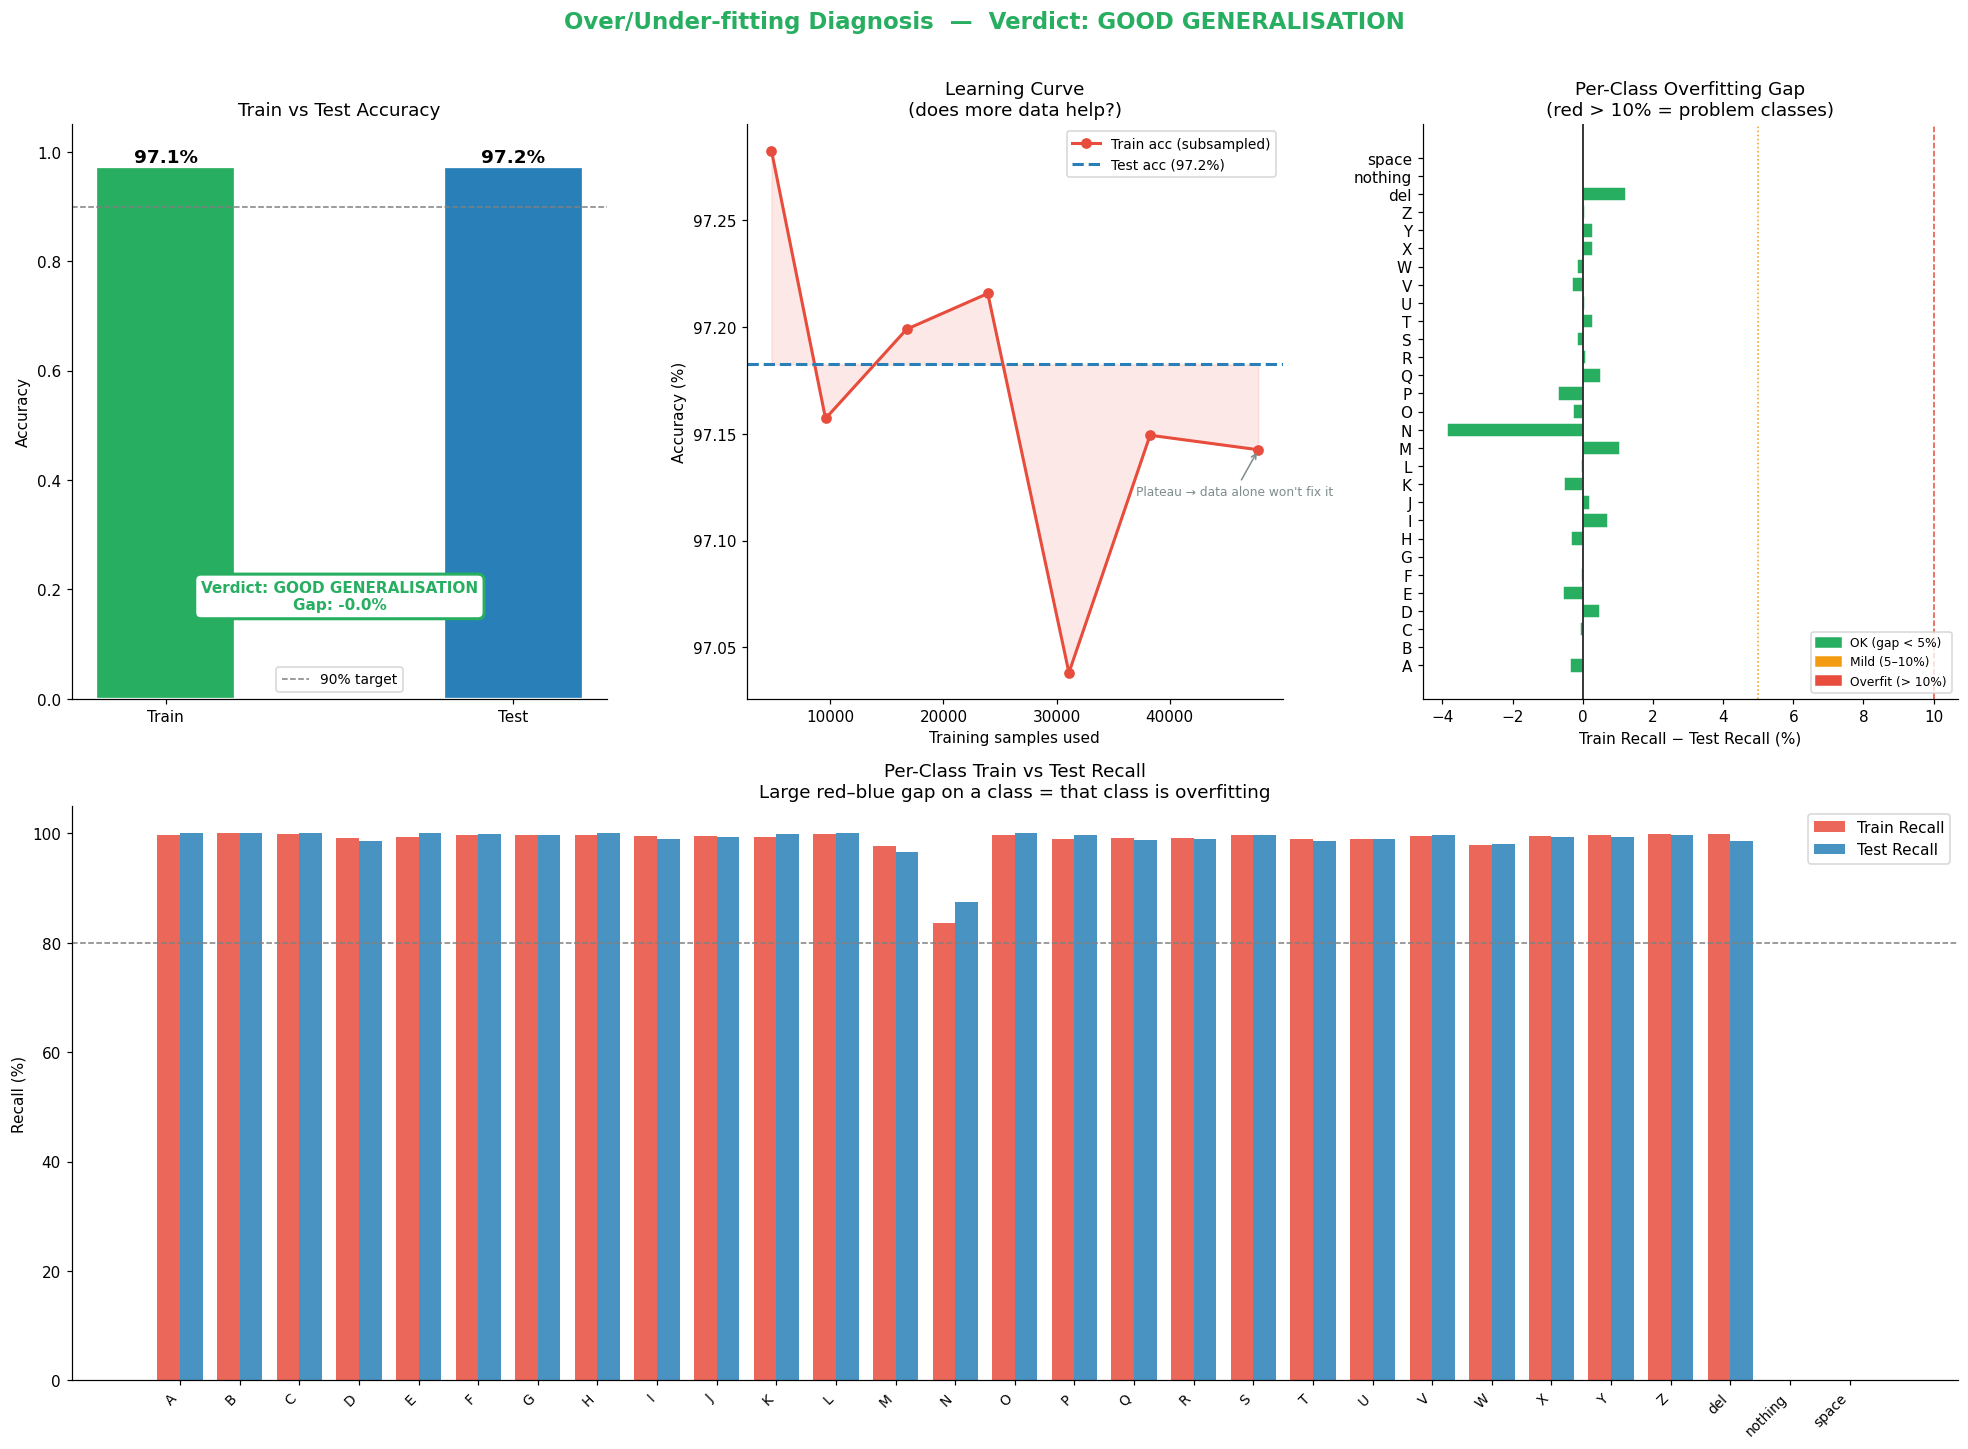

  DETAILED DIAGNOSIS
  Train accuracy  : 97.14%
  Test  accuracy  : 97.18%
  Generalisation gap: -0.04%

  No severe per-class overfitting detected.

  RECOMMENDED NEXT STEPS:
    1. Model generalises well on the held-out test set.
    2. → If live accuracy is still low, the problem is FEATURE DISTRIBUTION SHIFT:
    3. Live camera landmarks are in screen-space; training was on cropped images.
    4. Fix: use wrist-relative + scale normalization in extract_features().


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 4.5 — Over / Under-fitting Diagnosis
# Requires: model, X_train, X_test, y_train, y_test, CLASS_LABELS
# (all defined in earlier cells)
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import accuracy_score

# ── 1. TRAIN vs TEST ACCURACY ─────────────────────────────────────────────────
print("="*60)
print("  OVER / UNDER-FITTING DIAGNOSIS")
print("="*60)

train_probs = model.predict(X_train, batch_size=512, verbose=0)
train_pred  = np.argmax(train_probs, axis=1)
train_true  = np.argmax(y_train, axis=1) if y_train.ndim == 2 else y_train

test_probs  = model.predict(X_test,  batch_size=512, verbose=0)
test_pred   = np.argmax(test_probs,  axis=1)
test_true   = np.argmax(y_test,  axis=1) if y_test.ndim == 2 else y_test

train_acc = accuracy_score(train_true, train_pred)
test_acc  = accuracy_score(test_true,  test_pred)
gap       = train_acc - test_acc

print(f"  Train accuracy : {train_acc*100:.2f}%")
print(f"  Test  accuracy : {test_acc*100:.2f}%")
print(f"  Gap            : {gap*100:.2f}%")
print()

# ── Verdict ───────────────────────────────────────────────────────────────────
if train_acc < 0.80 and test_acc < 0.80:
    verdict = "UNDERFITTING"
    verdict_color = "#e74c3c"
    advice = (
        "Both train and test accuracy are LOW.\n"
        "→ Model is too simple, OR features are wrong/misaligned.\n"
        "  Check: Is extract_features() normalizing the same way as training?"
    )
elif gap > 0.15:
    verdict = "SEVERE OVERFITTING"
    verdict_color = "#c0392b"
    advice = (
        f"Train is {gap*100:.1f}% higher than test — model memorised training data.\n"
        "→ Increase Dropout (try 0.4–0.5), add L2 weight decay, or get more data.\n"
        "→ Alternatively, reduce model capacity (fewer neurons)."
    )
elif gap > 0.07:
    verdict = "MODERATE OVERFITTING"
    verdict_color = "#e67e22"
    advice = (
        f"Train is {gap*100:.1f}% higher than test — some overfitting present.\n"
        "→ Increase Dropout slightly (current: 0.2 → try 0.3).\n"
        "→ Add more training samples for low-recall classes (see Cell 11)."
    )
elif test_acc > 0.88:
    verdict = "GOOD GENERALISATION"
    verdict_color = "#27ae60"
    advice = (
        "Model generalises well on the held-out test set.\n"
        "→ If live accuracy is still low, the problem is FEATURE DISTRIBUTION SHIFT:\n"
        "  Live camera landmarks are in screen-space; training was on cropped images.\n"
        "  Fix: use wrist-relative + scale normalization in extract_features()."
    )
else:
    verdict = "MILD OVERFITTING / ROOM TO IMPROVE"
    verdict_color = "#f39c12"
    advice = (
        f"Gap of {gap*100:.1f}% is acceptable, but test accuracy ({test_acc*100:.1f}%) "
        "could be higher.\n"
        "→ Gather ~500 more samples per weak class (see per-class chart above).\n"
        "→ Try data augmentation: slight landmark jitter during training."
    )

print(f"  VERDICT: {verdict}")
print()
print("  ADVICE:")
for line in advice.split("\n"):
    print("  ", line)
print()

# ── 2. LEARNING CURVE ────────────────────────────────────────────────────────
# Evaluate at 10%, 20%, ..., 100% of training data (fast subsample, no retraining)
# This shows whether MORE DATA would help (underfitting: yes; overfitting: yes too)
fractions = [0.10, 0.20, 0.35, 0.50, 0.65, 0.80, 1.00]
lc_train, lc_test = [], []
rng = np.random.default_rng(42)

print("  Computing learning curve (subsampled, no retraining)...")
for frac in fractions:
    n = max(int(len(X_train) * frac), 1)
    idx = rng.choice(len(X_train), n, replace=False)
    p_tr = model.predict(X_train[idx], batch_size=512, verbose=0)
    y_tr = train_true[idx]
    lc_train.append(accuracy_score(y_tr, np.argmax(p_tr, axis=1)))
    lc_test.append(test_acc)   # test acc stays fixed

lc_sizes = [int(f * len(X_train)) for f in fractions]

# ── 3. PER-CLASS BIAS/VARIANCE ───────────────────────────────────────────────
# Per class: train recall vs test recall → gap tells you which classes overfit
from sklearn.metrics import classification_report
train_report = classification_report(train_true, train_pred,
                                     target_names=CLASS_LABELS, output_dict=True)
test_report  = classification_report(test_true,  test_pred,
                                     target_names=CLASS_LABELS, output_dict=True)

class_train_recall = [train_report[c]["recall"] for c in CLASS_LABELS]
class_test_recall  = [test_report[c]["recall"]  for c in CLASS_LABELS]
class_gap          = [tr - te for tr, te in zip(class_train_recall, class_test_recall)]

# ── PLOTS ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13))
fig.suptitle(
    f"Over/Under-fitting Diagnosis  —  Verdict: {verdict}",
    fontsize=15, fontweight="bold", color=verdict_color, y=1.01
)

# ── Panel A: Train vs Test bar ─────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
bars = ax1.bar(["Train", "Test"], [train_acc, test_acc],
               color=[verdict_color if gap > 0.07 else "#27ae60", "#2980b9"],
               width=0.4, edgecolor="white", linewidth=1.5)
ax1.set_ylim(0, 1.05)
ax1.axhline(0.90, color="gray", linestyle="--", linewidth=1, label="90% target")
for bar, val in zip(bars, [train_acc, test_acc]):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f"{val*100:.1f}%", ha="center", fontsize=12, fontweight="bold")
ax1.set_title("Train vs Test Accuracy", fontsize=12)
ax1.set_ylabel("Accuracy")
ax1.legend(fontsize=9)
ax1.spines[["top","right"]].set_visible(False)

# Verdict box
verdict_box = (
    f"Verdict: {verdict}\n"
    f"Gap: {gap*100:.1f}%"
)
ax1.text(0.5, 0.15, verdict_box, transform=ax1.transAxes,
         ha="center", va="bottom", fontsize=10, fontweight="bold",
         color=verdict_color,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                   edgecolor=verdict_color, linewidth=2))

# ── Panel B: Learning curve ────────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(lc_sizes, [v*100 for v in lc_train], "o-", color="#e74c3c",
         linewidth=2, markersize=6, label="Train acc (subsampled)")
ax2.axhline(test_acc*100, color="#2980b9", linestyle="--",
            linewidth=2, label=f"Test acc ({test_acc*100:.1f}%)")
ax2.fill_between(lc_sizes,
                 [v*100 for v in lc_train],
                 [test_acc*100]*len(lc_sizes),
                 alpha=0.12, color="#e74c3c")
ax2.set_xlabel("Training samples used")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Learning Curve\n(does more data help?)", fontsize=12)
ax2.legend(fontsize=9)
ax2.spines[["top","right"]].set_visible(False)

# Annotation: if train curve is still rising → more data would help
slope = lc_train[-1] - lc_train[-3]
note = "↑ Still rising → more data would help" if slope > 0.01 else "Plateau → data alone won\'t fix it"
ax2.annotate(note, xy=(lc_sizes[-1], lc_train[-1]*100),
             xytext=(-80, -30), textcoords="offset points",
             fontsize=8, color="#7f8c8d",
             arrowprops=dict(arrowstyle="->", color="#7f8c8d"))

# ── Panel C: Gap distribution histogram ────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
gap_pct = [g * 100 for g in class_gap]
colors_gap = ["#e74c3c" if g > 10 else "#f39c12" if g > 5 else "#27ae60"
              for g in gap_pct]
ax3.barh(CLASS_LABELS, gap_pct, color=colors_gap, edgecolor="white")
ax3.axvline(0,  color="black",   linewidth=1)
ax3.axvline(10, color="#e74c3c", linewidth=1, linestyle="--", label="10% overfit threshold")
ax3.axvline(5,  color="#f39c12", linewidth=1, linestyle=":",  label="5% mild overfit")
ax3.set_xlabel("Train Recall − Test Recall (%)")
ax3.set_title("Per-Class Overfitting Gap\n(red > 10% = problem classes)", fontsize=12)
ax3.legend(fontsize=8)
ax3.spines[["top","right"]].set_visible(False)
patch_ok  = mpatches.Patch(color="#27ae60", label="OK (gap < 5%)")
patch_mid = mpatches.Patch(color="#f39c12", label="Mild (5–10%)")
patch_bad = mpatches.Patch(color="#e74c3c", label="Overfit (> 10%)")
ax3.legend(handles=[patch_ok, patch_mid, patch_bad], fontsize=8, loc="lower right")

# ── Panel D: Per-class train vs test recall side by side ──────────────────────
ax4 = fig.add_subplot(2, 1, 2)
x = np.arange(len(CLASS_LABELS))
w = 0.38
ax4.bar(x - w/2, [v*100 for v in class_train_recall], width=w,
        label="Train Recall", color="#e74c3c", alpha=0.85)
ax4.bar(x + w/2, [v*100 for v in class_test_recall],  width=w,
        label="Test Recall",  color="#2980b9", alpha=0.85)
ax4.axhline(80, color="gray", linestyle="--", linewidth=1)
ax4.set_xticks(x)
ax4.set_xticklabels(CLASS_LABELS, rotation=45, ha="right", fontsize=9)
ax4.set_ylabel("Recall (%)")
ax4.set_title(
    "Per-Class Train vs Test Recall\n"
    "Large red–blue gap on a class = that class is overfitting",
    fontsize=12
)
ax4.legend(fontsize=10)
ax4.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

# ── Printed summary ────────────────────────────────────────────────────────────
print("="*60)
print("  DETAILED DIAGNOSIS")
print("="*60)
print(f"  Train accuracy  : {train_acc*100:.2f}%")
print(f"  Test  accuracy  : {test_acc*100:.2f}%")
print(f"  Generalisation gap: {gap*100:.2f}%")
print()
overfit_classes = sorted(
    [(CLASS_LABELS[i], class_gap[i]*100) for i in range(len(CLASS_LABELS))
     if class_gap[i] > 0.10],
    key=lambda x: -x[1]
)
if overfit_classes:
    print("  Most overfitting classes (train recall >> test recall):")
    for cls, g in overfit_classes[:8]:
        print(f"    {cls:12s}  gap = {g:.1f}%")
else:
    print("  No severe per-class overfitting detected.")
print()
print("  RECOMMENDED NEXT STEPS:")
for i, line in enumerate(advice.split("\n"), 1):
    if line.strip():
        print(f"    {i}. {line.strip()}")
print("="*60)

## 5. Per-Class F1 / Precision / Recall

**Red dashed line = 0.80.** Any bar below this is a problem class.
- Low recall → model misses the sign (predicts something else)
- Low precision → model fires this label when it should be something else


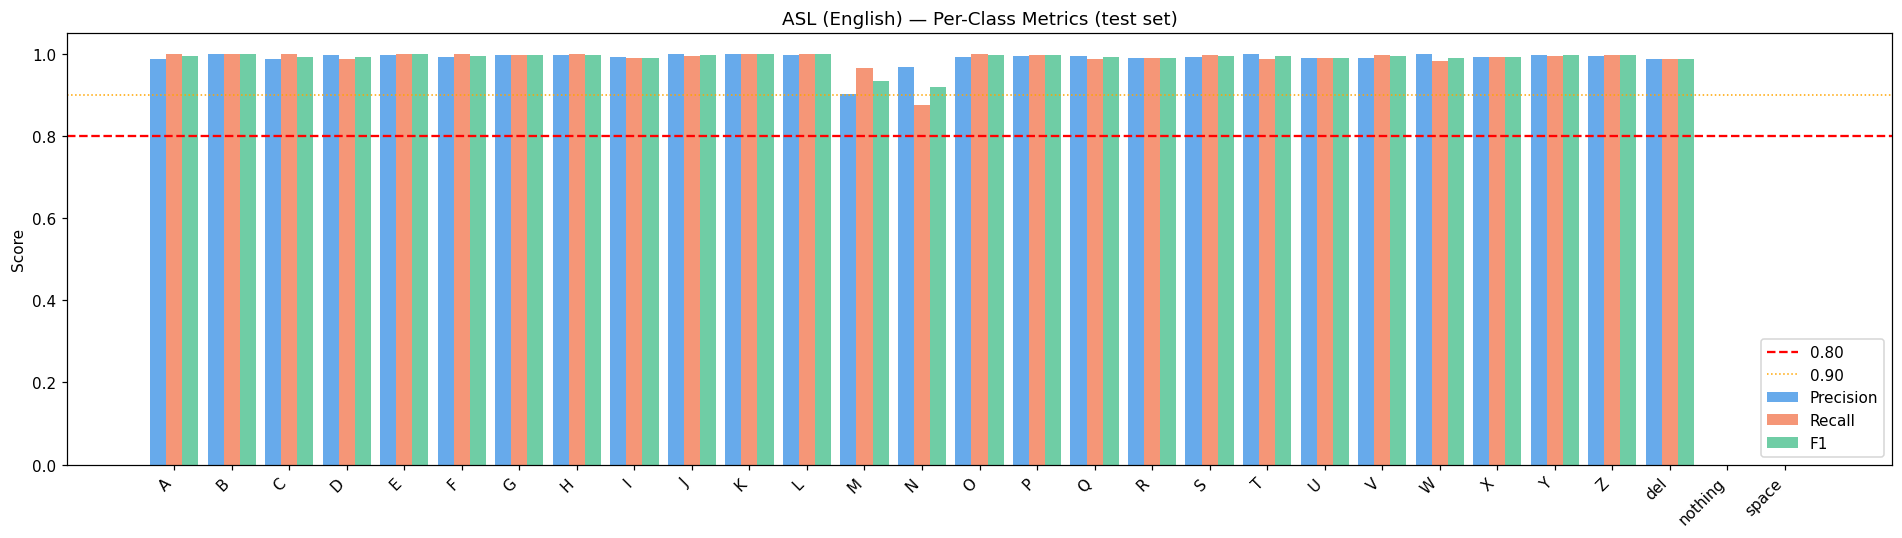


⚠ Lowest F1 classes:
  nothing  F1=0.000  P=0.000  R=0.000
  space   F1=0.000  P=0.000  R=0.000
  N       F1=0.918  P=0.967  R=0.874
  M       F1=0.933  P=0.902  R=0.966
  del     F1=0.986  P=0.986  R=0.986


In [7]:
per_class = report_df.loc[CLASS_LABELS][["precision","recall","f1-score"]].astype(float)

fig, ax = plt.subplots(figsize=(max(14, len(CLASS_LABELS)*0.6), 5))
x = np.arange(len(CLASS_LABELS)); w = 0.28
ax.bar(x-w, per_class["precision"], w, label="Precision", color="#4C9BE8", alpha=0.85)
ax.bar(x,   per_class["recall"],    w, label="Recall",    color="#F4845F", alpha=0.85)
ax.bar(x+w, per_class["f1-score"],  w, label="F1",        color="#56C596", alpha=0.85)
ax.axhline(0.80, color="red",    linestyle="--", lw=1.5, label="0.80")
ax.axhline(0.90, color="orange", linestyle=":",  lw=1.0, label="0.90")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_LABELS, rotation=45 if len(CLASS_LABELS)>20 else 0, ha="right")
ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
ax.set_title(f"{TITLE_PREFIX} — Per-Class Metrics (test set)")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

worst = per_class["f1-score"].nsmallest(5)
print("\n⚠ Lowest F1 classes:")
for cls, val in worst.items():
   print(f"  {cls:<6}  F1={val:.3f}  P={per_class.loc[cls,'precision']:.3f}  R={per_class.loc[cls,'recall']:.3f}")

## 6. Confusion Matrix

Diagonal suppressed so errors are visible. Off-diagonal bright cells = pairs that confuse each other.


C:\Users\HADEEL GAMALELDIN\AppData\Local\Temp\ipykernel_23936\892818720.py:2: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)


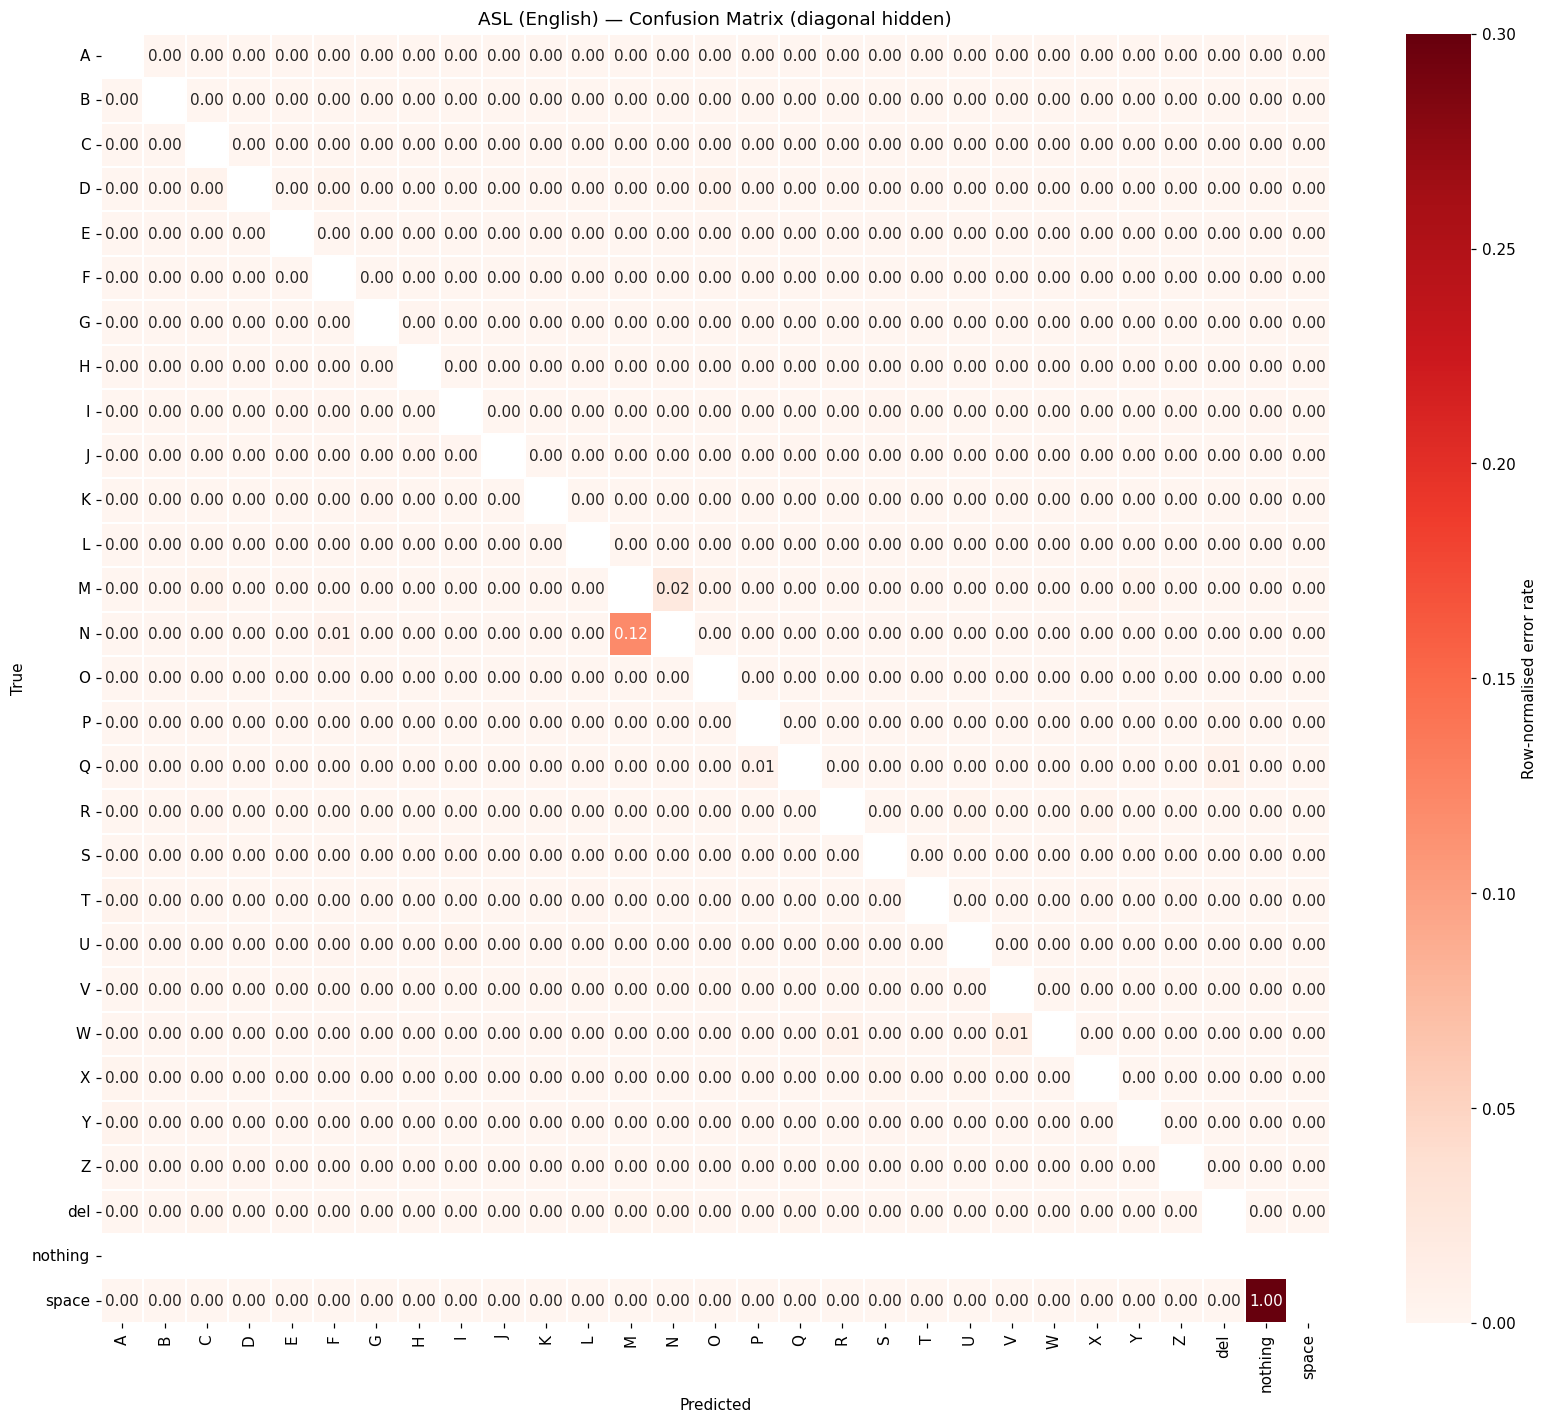


🔥 Top-10 confused pairs (True → Predicted):
  space  → nothing  100.0%
  N      → M       12.1%
  M      → N       2.1%
  W      → V       1.0%
  Q      → del     0.8%
  W      → R       0.6%
  Q      → P       0.5%
  N      → F       0.5%
  T      → A       0.4%
  D      → C       0.4%


In [8]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
n       = len(CLASS_LABELS)

fig, ax = plt.subplots(figsize=(max(14, n*0.52), max(11, n*0.45)))
mask    = np.eye(n, dtype=bool)
sns.heatmap(cm_norm, annot=(n<=32), fmt=".2f", cmap="Reds",
            linewidths=0.3, xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
            ax=ax, mask=mask, vmin=0, vmax=0.3,
            cbar_kws={"label":"Row-normalised error rate"})
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"{TITLE_PREFIX} — Confusion Matrix (diagonal hidden)")
plt.tight_layout(); plt.show()

cm_nd = cm_norm.copy(); np.fill_diagonal(cm_nd, 0)
pairs = [(CLASS_LABELS[i], CLASS_LABELS[j], cm_nd[i,j])
         for i in range(n) for j in range(n) if i!=j and cm_nd[i,j]>0]
pairs.sort(key=lambda x: -x[2])
print("\n🔥 Top-10 confused pairs (True → Predicted):")
for t,p,r in pairs[:10]:
    print(f"  {t:<6} → {p:<6}  {r*100:.1f}%")

## 7. Confidence Distribution & Threshold Sweep

**Left plot:** green = correct predictions, red = incorrect — see where they overlap.
**Right plot:** sweep the threshold and read off the coverage/precision trade-off.

- Histogram peaked near 1.0 → model is confident; threshold is fine → problem is camera/lighting
- Long tail below 0.75 → threshold is filtering valid preds → lower it OR retrain


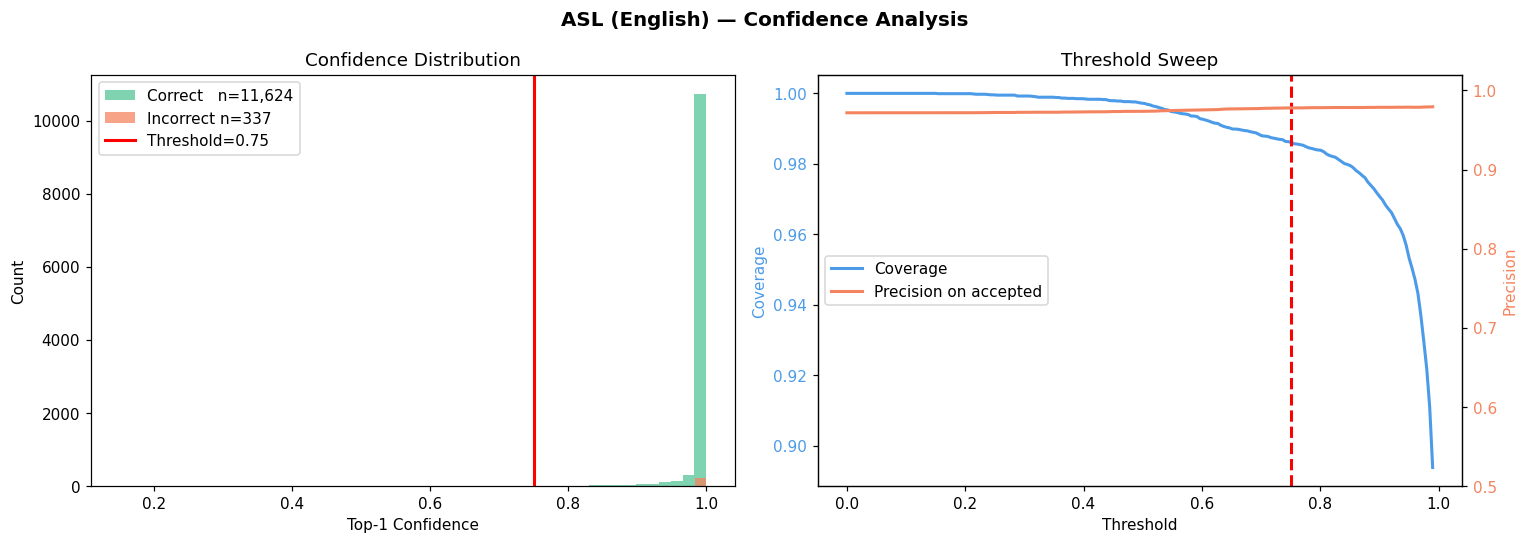

At threshold=0.75:
  Accepted : 98.6%  |  Precision on accepted: 97.80%
  Rejected : 1.4% — these show 'Low confidence' live

💡 Threshold for 90% coverage : 0.99  (precision=97.94%)


In [9]:
CURRENT_THRESHOLD = 0.75

correct_c   = y_conf[y_pred == y_test]
incorrect_c = y_conf[y_pred != y_test]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(correct_c,   bins=50, color="#56C596", alpha=0.75, label=f"Correct   n={len(correct_c):,}")
ax.hist(incorrect_c, bins=50, color="#F4845F", alpha=0.75, label=f"Incorrect n={len(incorrect_c):,}")
ax.axvline(CURRENT_THRESHOLD, color="red", lw=2, label=f"Threshold={CURRENT_THRESHOLD}")
ax.set_xlabel("Top-1 Confidence"); ax.set_ylabel("Count")
ax.set_title("Confidence Distribution"); ax.legend()

thresholds = np.linspace(0.0, 0.99, 200)
coverages  = []
precisions = []
for t in thresholds:
    mask = y_conf >= t
    coverages.append(mask.mean())
    precisions.append((y_pred[mask]==y_test[mask]).mean() if mask.sum()>0 else 1.0)

ax2 = axes[1]
ln1 = ax2.plot(thresholds, coverages,  color="#4C9BE8", lw=2, label="Coverage")
ax2.set_ylabel("Coverage", color="#4C9BE8"); ax2.tick_params(axis="y", labelcolor="#4C9BE8")
ax2b = ax2.twinx()
ln2 = ax2b.plot(thresholds, precisions, color="#F4845F", lw=2, label="Precision on accepted")
ax2b.set_ylabel("Precision", color="#F4845F"); ax2b.tick_params(axis="y", labelcolor="#F4845F")
ax2b.set_ylim(0.5, 1.02)
ax2.axvline(CURRENT_THRESHOLD, color="red", lw=2, linestyle="--")
ax2.set_xlabel("Threshold")
ax2.set_title("Threshold Sweep")
lines = ln1+ln2; ax2.legend(lines, [l.get_label() for l in lines], loc="center left")

plt.suptitle(f"{TITLE_PREFIX} — Confidence Analysis", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

mask = y_conf >= CURRENT_THRESHOLD
cov  = mask.mean()
prec = (y_pred[mask]==y_test[mask]).mean() if mask.sum()>0 else 0
print(f"At threshold={CURRENT_THRESHOLD}:")
print(f"  Accepted : {cov*100:.1f}%  |  Precision on accepted: {prec*100:.2f}%")
print(f"  Rejected : {(1-cov)*100:.1f}% — these show 'Low confidence' live\n")

idx90 = np.argmin(np.abs(np.array(coverages)-0.90))
print(f"💡 Threshold for 90% coverage : {thresholds[idx90]:.2f}  (precision={precisions[idx90]*100:.2f}%)")

## 8. Per-Class Confidence Box Plot

Sorted worst → best. Red = median below threshold. Classes with low/spread boxes will feel "shaky" live regardless of threshold.


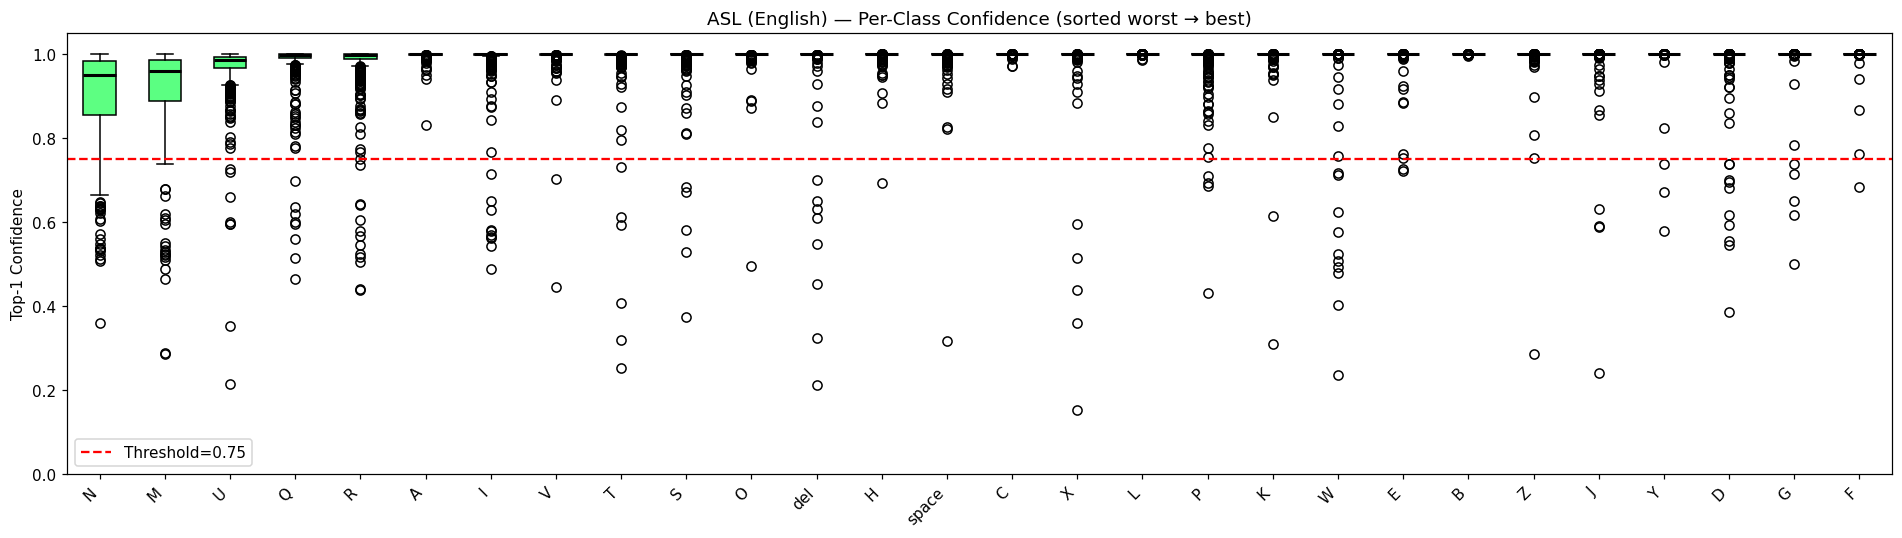

✓ All class medians above threshold.
  If live is still shaky → domain gap (lighting/angle), not model quality.


In [10]:
conf_by_class = {lbl:[] for lbl in CLASS_LABELS}
for i, ti in enumerate(y_test):
    conf_by_class[CLASS_LABELS[ti]].append(y_conf[i])

medians = {k: np.median(v) for k,v in conf_by_class.items() if v}
sorted_labels = sorted(medians, key=medians.get)
data_sorted   = [conf_by_class[lbl] for lbl in sorted_labels]

fig, ax = plt.subplots(figsize=(max(14, len(CLASS_LABELS)*0.6), 5))
bp = ax.boxplot(data_sorted, patch_artist=True, notch=False,
                medianprops=dict(color="black", lw=2))
for patch, lbl in zip(bp["boxes"], sorted_labels):
    m = medians[lbl]
    patch.set_facecolor((max(0,min(1,2*(1-m))), max(0,min(1,2*m)), 0.3, 0.7))

ax.axhline(CURRENT_THRESHOLD, color="red", linestyle="--", lw=1.5,
           label=f"Threshold={CURRENT_THRESHOLD}")
ax.set_xticks(range(1,len(sorted_labels)+1))
ax.set_xticklabels(sorted_labels, rotation=45 if len(CLASS_LABELS)>20 else 0, ha="right")
ax.set_ylim(0, 1.05); ax.set_ylabel("Top-1 Confidence")
ax.set_title(f"{TITLE_PREFIX} — Per-Class Confidence (sorted worst → best)")
ax.legend(); plt.tight_layout(); plt.show()

weak = [(lbl, medians[lbl]) for lbl in sorted_labels if medians[lbl]<CURRENT_THRESHOLD]
if weak:
    print("⚠ Classes with median confidence BELOW threshold:")
    for lbl, m in weak:
        print(f"  {lbl:<6}  median={m:.3f}")
else:
    print("✓ All class medians above threshold.")
    print("  If live is still shaky → domain gap (lighting/angle), not model quality.")

## 9. Dataset Balance Check

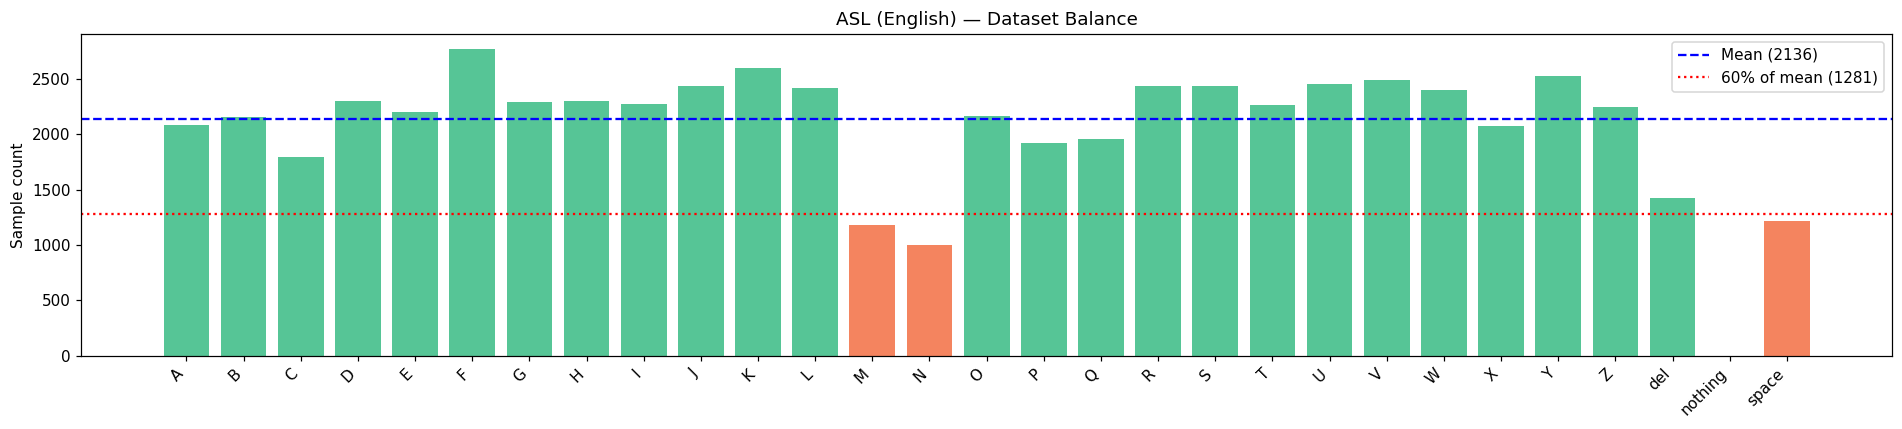

⚠ Under-represented classes:
  nothing  0 samples
  N       996 samples
  M       1,183 samples
  space   1,217 samples


In [11]:
label_counts  = df[label_col].value_counts()
avg_count     = label_counts.mean()
thresh_low    = avg_count * 0.60

fig, ax = plt.subplots(figsize=(max(14, len(CLASS_LABELS)*0.6), 4))
colors = ["#F4845F" if label_counts.get(l,0)<thresh_low else "#56C596" for l in CLASS_LABELS]
ax.bar(CLASS_LABELS, [label_counts.get(l,0) for l in CLASS_LABELS], color=colors)
ax.axhline(avg_count,  color="blue", linestyle="--", lw=1.5, label=f"Mean ({avg_count:.0f})")
ax.axhline(thresh_low, color="red",  linestyle=":",  lw=1.5, label=f"60% of mean ({thresh_low:.0f})")
plt.xticks(rotation=45 if len(CLASS_LABELS)>20 else 0, ha="right")
ax.set_ylabel("Sample count")
ax.set_title(f"{TITLE_PREFIX} — Dataset Balance")
ax.legend(); plt.tight_layout(); plt.show()

under = [(l, int(label_counts.get(l,0))) for l in CLASS_LABELS if label_counts.get(l,0)<thresh_low]
if under:
    print("⚠ Under-represented classes:")
    for l,c in sorted(under, key=lambda x:x[1]):
        print(f"  {l:<6}  {c:,} samples")
else:
    print("✓ Dataset is balanced.")

## 10. Automated Diagnosis Summary

Rule-based check across all metrics. Read top to bottom — fix CRITICAL issues first.


In [12]:
issues = []

# 1. Overall accuracy
if acc1 < 0.85:
    issues.append(("CRITICAL", f"Top-1 accuracy is {acc1*100:.1f}%. Model needs retraining or a larger architecture."))
elif acc1 < 0.92:
    issues.append(("WARNING",  f"Top-1 accuracy is {acc1*100:.1f}%. Fine-tuning on hard samples may help."))
else:
    issues.append(("OK",       f"Top-1 accuracy is {acc1*100:.1f}%. Model itself is not the bottleneck."))

# 2. Top-1 vs Top-2 gap
gap = acc2 - acc1
if gap > 0.06:
    confused = [f"{t}→{p}" for t,p,_ in pairs[:5]]
    issues.append(("WARNING", f"Top-2 gap = {gap*100:.1f}pp. Correct class is often 2nd. Main confused pairs: {', '.join(confused)}. Need targeted data or dynamic features for these."))
else:
    issues.append(("OK", f"Top-2 gap = {gap*100:.1f}pp. Model ranks the correct class confidently."))

# 3. Threshold coverage
mask = y_conf >= CURRENT_THRESHOLD; cov = mask.mean()
if cov < 0.70:
    issues.append(("CRITICAL", f"Threshold=0.75 accepts only {cov*100:.1f}% of predictions. Lower to {thresholds[idx90]:.2f} (90% coverage) or collect more varied training data."))
elif cov < 0.85:
    issues.append(("WARNING",  f"Threshold=0.75 accepts {cov*100:.1f}%. Some signs will feel unresponsive. Consider threshold={thresholds[idx90]:.2f}."))
else:
    issues.append(("OK",       f"Threshold accepts {cov*100:.1f}%. If live is still slow, check lighting/hand position (domain gap)."))

# 4. Per-class weak letters
wc = [l for l in CLASS_LABELS if per_class.loc[l,"f1-score"]<0.80]
if wc:
    issues.append(("WARNING", f"F1 < 0.80 for: {', '.join(wc)}. Collect more/better samples for these or check if they are inherently ambiguous with static keypoints."))
else:
    issues.append(("OK", "All classes have F1 >= 0.80."))

# 5. Dataset imbalance
if under:
    issues.append(("WARNING", f"Under-represented: {', '.join([l for l,_ in under])}. Augment or collect more samples."))
else:
    issues.append(("OK", "Dataset is balanced."))

# Print sorted by severity
order = {"CRITICAL":0,"WARNING":1,"OK":2}
icons = {"CRITICAL":"🔴","WARNING":"🟡","OK":"🟢"}
print("=" * 62)
print(f"  DIAGNOSIS SUMMARY — {TITLE_PREFIX}")
print("=" * 62)
for level, msg in sorted(issues, key=lambda x: order[x[0]]):
    print(f"\n{icons[level]} [{level}]  {msg}")
print("\n" + "=" * 62)

  DIAGNOSIS SUMMARY — ASL (English)

🟡 [WARNING]  F1 < 0.80 for: nothing, space. Collect more/better samples for these or check if they are inherently ambiguous with static keypoints.

🟡 [WARNING]  Under-represented: M, N, nothing, space. Augment or collect more samples.

🟢 [OK]  Top-1 accuracy is 97.2%. Model itself is not the bottleneck.

🟢 [OK]  Top-2 gap = 2.6pp. Model ranks the correct class confidently.

🟢 [OK]  Threshold accepts 98.6%. If live is still slow, check lighting/hand position (domain gap).



## 11. Live Diagnostics — Real-Time Probability Viewer

Runs the webcam + model and shows the **raw probability bar for every class** in real time.

**How to read it:**
- 🟢 Green bar = top-1 prediction
- 🔵 Cyan bar = above threshold but not top-1
- ⚫ Grey bar = below threshold
- Red vertical line = threshold

**Scenarios you can diagnose live:**
- Green bar is tall but doesn't cross the red line → lower the threshold
- Green bar is short and spread across many grey bars → model is uncertain; need more training data
- Green bar keeps switching between two classes → those two signs look too similar statically; need dynamic modelling
- Green bar is tall and crosses line but detection is slow → stabilisation window is too long

Controls: **q** = quit


In [13]:
class _ThrCam:
    def __init__(self, src=0):
        self.cap = cv2.VideoCapture(src)
        self.cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)
        self._q = queue.Queue(maxsize=1); self._ok = True
        self._t = threading.Thread(target=self._r, daemon=True); self._t.start()
    def _r(self):
        while self._ok:
            ret, f = self.cap.read()
            if ret:
                if not self._q.empty():
                    try: self._q.get_nowait()
                    except: pass
                self._q.put(f)
    def read(self): return self._q.get()
    def release(self):
        self._ok=False; self._t.join(timeout=2); self.cap.release()

_mph  = mp.solutions.hands
_mpd  = mp.solutions.drawing_utils
_hdet = _mph.Hands(static_image_mode=False, max_num_hands=1,
                    min_detection_confidence=0.70, min_tracking_confidence=0.65)

@tf.function(input_signature=[tf.TensorSpec(shape=[1,63], dtype=tf.float32)])
def _inf(x): return model(x, training=False)
_ = _inf(tf.zeros([1,63], dtype=tf.float32))

CAM_W, CAM_H = 640, 480
CHART_W = 380
WIN_W   = CAM_W + CHART_W
N       = len(CLASS_LABELS)
ROW_H   = max(10, CAM_H // N)
BAR_MAX = CHART_W - 90
DIAG_T  = 0.75

def run_live_diagnostics():
    cam = _ThrCam(src=0)
    cv2.namedWindow("SLR Live Diagnostics", cv2.WINDOW_NORMAL)
    cv2.resizeWindow("SLR Live Diagnostics", WIN_W, CAM_H)
    print("🔍 Live diagnostics — q to quit")
    try:
        while True:
            frame = cam.read()
            frame = cv2.resize(frame, (CAM_W, CAM_H))
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            rgb.flags.writeable = False
            res = _hdet.process(rgb)
            rgb.flags.writeable = True
            plive = np.zeros(N, dtype=np.float32)
            top_lbl, top_cf = "No hand", 0.0
            if res.multi_hand_landmarks:
                _mpd.draw_landmarks(frame, res.multi_hand_landmarks[0], _mph.HAND_CONNECTIONS)
                lm = res.multi_hand_landmarks[0].landmark
                feat = np.array([[p.x,p.y,p.z] for p in lm], dtype=np.float32).reshape(1,-1)
                plive = _inf(tf.constant(feat))[0].numpy()
                ti = int(np.argmax(plive)); top_cf = float(plive[ti]); top_lbl = CLASS_LABELS[ti]

            # Chart panel
            panel = np.full((CAM_H, CHART_W, 3), 25, dtype=np.uint8)
            order = np.argsort(plive)[::-1]
            for rank, ci in enumerate(order):
                yt = rank * ROW_H; yb = yt + ROW_H - 2
                if yb >= CAM_H: break
                p = float(plive[ci])
                bw = int(p * BAR_MAX)
                clr = (80,220,100) if ci==order[0] else (60,200,230) if p>=DIAG_T else (70,70,70)
                cv2.rectangle(panel, (60, yt+1), (60+bw, yb), clr, -1)
                fs = max(0.27, min(0.42, ROW_H/25))
                cv2.putText(panel, CLASS_LABELS[ci], (2, yt+ROW_H-4),
                            cv2.FONT_HERSHEY_SIMPLEX, fs, (210,210,210), 1)
                cv2.putText(panel, f"{p*100:4.1f}%", (62+bw, yt+ROW_H-4),
                            cv2.FONT_HERSHEY_SIMPLEX, fs*0.85, (170,170,170), 1)

            tx = 60 + int(DIAG_T * BAR_MAX)
            cv2.line(panel, (tx,0), (tx,CAM_H), (0,60,220), 1)
            cv2.putText(panel, f"T={DIAG_T}", (tx+2, 11),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,100,255), 1)

            # Status overlay on camera
            cv2.rectangle(frame, (0,0), (CAM_W,42), (30,30,30), -1)
            col = (0,255,0) if top_cf>=DIAG_T else (0,160,255) if top_cf>0 else (150,150,150)
            cv2.putText(frame, f"Top: {top_lbl}  {top_cf:.0%}",
                        (10,29), cv2.FONT_HERSHEY_SIMPLEX, 0.85, col, 2)

            cv2.imshow("SLR Live Diagnostics", np.hstack([frame, panel]))
            if cv2.waitKey(1) & 0xFF == ord("q"): break
    finally:
        cam.release(); cv2.destroyAllWindows()
        print("Closed.")

run_live_diagnostics()

🔍 Live diagnostics — q to quit
Closed.
